In [1]:
!pip install pennylane
!pip install pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 80.0 MB/s eta 0:00:00


# Import Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
dev = qml.device("lightning.qubit", wires=4)

# Configuration

In [4]:
DATASET_PATH = "/kaggle/input/datasets/ashenafifasilkebede/dataset"

IMAGE_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 5
LR = 0.001

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# Image Preprocessing

Histopathology images can have different sizes, so we resize and normalize.

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Load Dataset

In [6]:
from torchvision import datasets
import os

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"test"),
    transform=transform
)

# Data Loaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE)

# Check Classes and dataset size

In [8]:
print("Class mapping:", train_dataset.class_to_idx)

print("\nDataset size")
print("Train:",len(train_dataset))
print("Validation:",len(val_dataset))
print("Test:",len(test_dataset))

Class mapping: {'Normal': 0, 'OSCC': 1}

Dataset size
Train: 4946
Validation: 120
Test: 126


# Visualize images

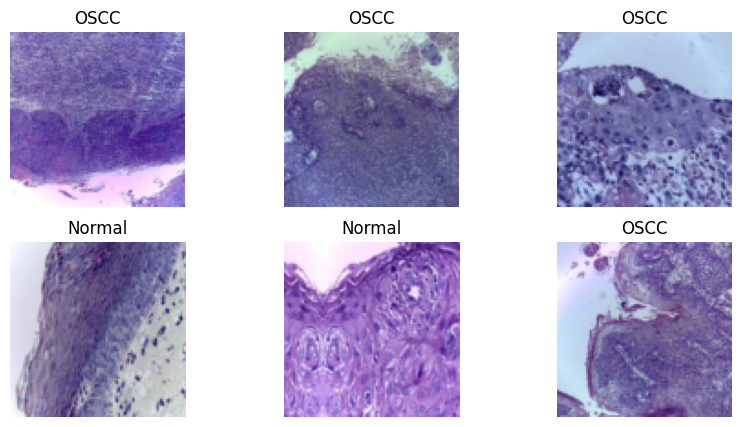

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    img = images[i] * 0.5 + 0.5   # undo normalization
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

# Build Classical CNN

In [10]:
class ClassicalCNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*12*12,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )
        
    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Initialize Model

In [11]:
model = ClassicalCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training Loop

In [12]:
for epoch in range(EPOCHS):

    model.train()
    
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1} Loss {epoch_loss:.4f} Accuracy {acc:.2f}%")

Epoch 1 Loss 0.6155 Accuracy 65.73%
Epoch 2 Loss 0.5382 Accuracy 71.96%
Epoch 3 Loss 0.4488 Accuracy 78.55%
Epoch 4 Loss 0.3735 Accuracy 83.18%
Epoch 5 Loss 0.3137 Accuracy 85.95%


# Evaluate CNN

In [13]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      Normal       0.64      0.94      0.76        31
        OSCC       0.98      0.83      0.90        95

    accuracy                           0.86       126
   macro avg       0.81      0.88      0.83       126
weighted avg       0.89      0.86      0.86       126



# Quantum Circuit

This circuit does three things:

• encodes features
• entangles qubits
• applies trainable gates

In [14]:
n_qubits = 4

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")

def quantum_circuit(inputs, weights):

    # Angle Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Entanglement
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])

    # Trainable Rotations
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Convert Circuit to a PyTorch Layer

In [15]:
weight_shapes = {"weights": (n_qubits)}

qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# Hybrid QCNN Model

In [16]:
class HybridQCNN(nn.Module):

    def __init__(self):
        super(HybridQCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64*12*12,4)

        self.qlayer = qlayer

        self.fc2 = nn.Linear(4,2)


    def forward(self, x):

        x = self.conv(x)

        x = self.flatten(x)

        x = self.fc1(x)

        q_out = []

        for i in range(x.shape[0]):
            q_out.append(self.qlayer(x[i]))

        x = torch.stack(q_out)

        x = self.fc2(x)

        return x

# Initialize the Hybrid Model

In [17]:
model = HybridQCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Train Hybrid QCNN

In [18]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1} Loss {epoch_loss:.4f} Accuracy {epoch_acc:.2f}%")

Epoch 1 Loss 0.6373 Accuracy 63.36%
Epoch 2 Loss 0.5745 Accuracy 70.18%
Epoch 3 Loss 0.5157 Accuracy 75.13%
Epoch 4 Loss 0.4715 Accuracy 78.85%
Epoch 5 Loss 0.3983 Accuracy 82.90%


# Evaluate Hybrid Model

In [19]:
model.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.3627
Test Accuracy: 88.10%
